# High-Value Customer Behavior Simulation for a FinTech Subscription Service

## Section S00 — Data Pipeline Overview

This notebook summarizes the reusable project pipeline implemented in `src/`.
It focuses on how raw VIP customer data is generated, corrupted, repaired, and analyzed.


In [1]:
from src.notebook_utils import ensure_project_root_on_path, RAW_DATA, CHECKPOINT_DATA, SYNTHETIC_DIR
ensure_project_root_on_path()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')

from src.workflows import run_generation_workflow, summarize_dataset, compare_numeric_columns

outputs = run_generation_workflow(
    samples=1000,
    random_state=42,
    raw_output=RAW_DATA,
    checkpoint_output=CHECKPOINT_DATA,
)

raw_df = outputs['raw']
checkpoint_df = outputs['checkpoint']
print(f'Raw dataset saved to: {RAW_DATA}')
print(f'Checkpoint dataset saved to: {CHECKPOINT_DATA}')
raw_df.head()


Raw dataset saved to: /Users/rserban/TST/DEV/PYTHON/WORK/GITHUB_REPOS/GITHUB_KFLOW_DEV/data-services-portfolio/projects/artificial-data-generation/data/raw/vip_seed.csv
Checkpoint dataset saved to: /Users/rserban/TST/DEV/PYTHON/WORK/GITHUB_REPOS/GITHUB_KFLOW_DEV/data-services-portfolio/projects/artificial-data-generation/data/checkpoints/vip_seed.csv


,avg_transaction,frequency,credit_score,vip_status
0,55.66,14,737.0,0
1,41.71,11,663.0,0
2,63.73,7,761.0,0
3,38.31,14,772.0,0
4,43.33,14,613.0,0


In [2]:
summary = summarize_dataset(raw_df)
summary


,count,mean,std,min,25%,50%,75%,max
avg_transaction,1000.0,50.66778,21.106595,5.0,36.5425,47.08,60.8675,189.78
frequency,1000.0,11.80200,3.509860,3.0,9.0000,12.00,14.0000,22.00
credit_score,1000.0,718.28000,54.019346,519.0,682.0000,720.00,752.0000,850.00
vip_status,1000.0,0.02700,0.162164,0.0,0.0000,0.00,0.0000,1.00


In [3]:
comparison = compare_numeric_columns(raw_df, checkpoint_df)
comparison


,column,real_mean,synthetic_mean,mean_delta,kl_divergence
0,avg_transaction,50.66778,53.273516,2.605736,0.016163
1,frequency,11.80200,11.776675,-0.025325,0.005964
2,credit_score,718.28000,714.597576,-3.682424,0.017905


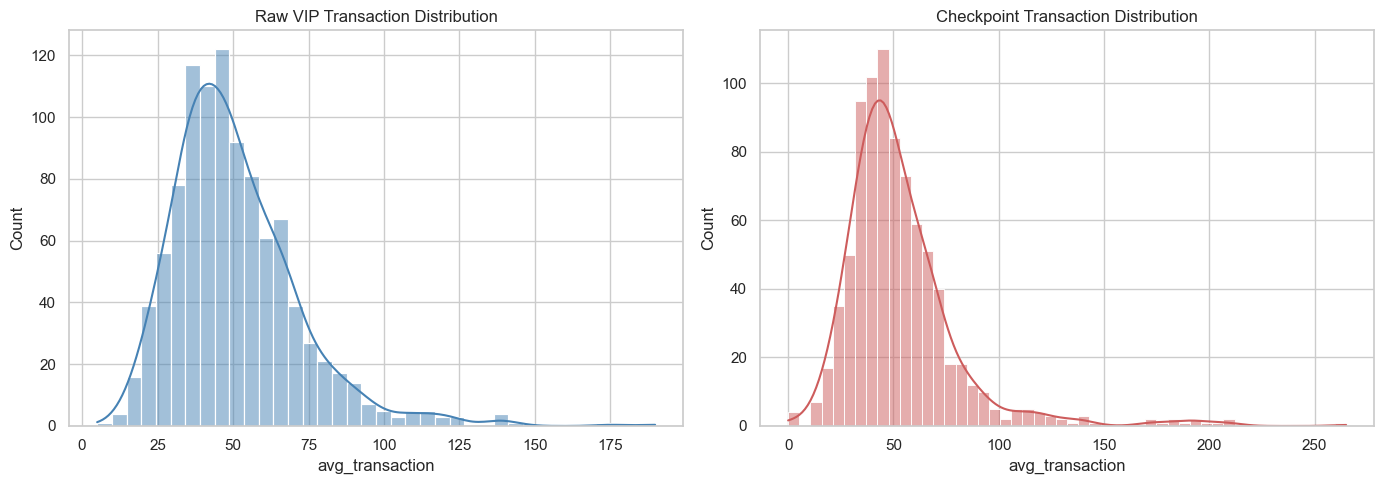

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(raw_df['avg_transaction'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Raw VIP Transaction Distribution')
sns.histplot(checkpoint_df['avg_transaction'].dropna(), kde=True, ax=axes[1], color='indianred')
axes[1].set_title('Checkpoint Transaction Distribution')
plt.tight_layout()
